# TFM – Marketing Fintech Campaign Analysis

<a id="indice"></a>
## Índice

- [Introducción](#introduccion)
- [Imports](#imports)
- [Carga de datos](#carga-datos)
- [Exploración de datos inicial](#exploracion)
- [Visualización de los datos](#visualizacion)
- [Análisis de los datos](#analisis)
- [KPIs](#kpis)
- [Conclusiones](#conclusiones)


<a id="introduccion"></a>
## Introducción 📑

Este Notebook forma parte del **Trabajo Final de Máster (TFM)** enfocado al análisis de datos en el ámbito del marketing financiero.

El objetivo del proyecto es **analizar la información procedente de campañas de marketing telefónicas realizadas por una entidad bancaria**, con el fin de comprender qué factores influyen en la decisión de los clientes de contratar un depósito a plazo fijo.

A partir del análisis del dataset se busca identificar **patrones de comportamiento, variables relevantes y segmentos de clientes** que presenten mayor probabilidad de conversión.

En este documento se desarrollan las primeras fases del proyecto:

1. **Carga y revisión inicial del dataset**  
   - Importación del conjunto de datos y comprobación de su estructura.  
   - Análisis general del número de variables, tipos de datos y consistencia de la información.  
   - Primera inspección del contenido del dataset.

2. **Preparación y exploración inicial de los datos**  
   - Identificación de posibles valores problemáticos (categorías desconocidas, valores atípicos o inconsistencias).  
   - Evaluación de la calidad del dataset.  
   - Creación o transformación de variables que permitan enriquecer el análisis posterior.

3. **Análisis exploratorio de datos (EDA)**  
   - Estudio de variables demográficas como edad, profesión, nivel educativo o estado civil.  
   - Análisis de variables relacionadas con la campaña de marketing, como el tipo de contacto, el número de interacciones o la duración de las llamadas.  
   - Evaluación de la respuesta de los clientes ante la campaña (`y`).

4. **Análisis de relaciones entre variables**  
   - Comparación de diferentes segmentos de clientes según su comportamiento frente a la campaña.  
   - Identificación de patrones y posibles factores asociados a una mayor probabilidad de conversión.

5. **Modelo predictivo de conversión**  
   - Desarrollo de un modelo de predicción cuyo objetivo es estimar la probabilidad de que un cliente acepte la oferta del depósito a plazo fijo (`y = yes`).  
   - Evaluación del rendimiento del modelo y análisis de las variables con mayor capacidad predictiva.

El propósito de este análisis es **comprender mejor los factores que influyen en la efectividad de las campañas de marketing**, así como proporcionar información útil para mejorar la segmentación de clientes y optimizar futuras estrategias comerciales.

[⬆ Volver al índice](#indice)

<a id="imports"></a>
## Imports 📦

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from functions import *
from matplotlib import rcParams

# Expresiones regulares
import re
from fuzzywuzzy import process

/opt/anaconda3/envs/test/lib/python3.13/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


[⬆ Volver al índice](#indice)

<a id="carga-datos"></a>
## Carga de datos 📂

In [2]:
df = pd.read_csv('../Data/bank-additional_bank-additional-full.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


[⬆ Volver al índice](#indice)

<a id="exploracion"></a>
## Exploración de datos inicial 🔎

In [3]:
check_df(df)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 41,188 filas y 21 columnas.

##########################################################################################

¿Cuáles son las primeras 5 filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



##########################################################################################

¿Cuáles son las últimas cinco filas del conjunto de datos?


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no



##########################################################################################

¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



##########################################################################################

Estadísticas descriptivas (categóricas):


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548



##########################################################################################



(       age  duration  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
 0       56       261         1    999         0           1.1          93.994   
 1       57       149         1    999         0           1.1          93.994   
 2       37       226         1    999         0           1.1          93.994   
 3       40       151         1    999         0           1.1          93.994   
 4       56       307         1    999         0           1.1          93.994   
 ...    ...       ...       ...    ...       ...           ...             ...   
 41183   73       334         1    999         0          -1.1          94.767   
 41184   46       383         1    999         0          -1.1          94.767   
 41185   56       189         2    999         0          -1.1          94.767   
 41186   44       442         1    999         0          -1.1          94.767   
 41187   74       239         3    999         1          -1.1          94.767   
 
        cons.c

In [4]:
identificacion_valores_problem(df)

###################################################################################
3.1.1. Proporción de NULOS en cada una de las columnas del conjunto de datos:
age               0.0
campaign          0.0
nr.employed       0.0
euribor3m         0.0
cons.conf.idx     0.0
cons.price.idx    0.0
emp.var.rate      0.0
poutcome          0.0
previous          0.0
pdays             0.0
duration          0.0
job               0.0
day_of_week       0.0
month             0.0
contact           0.0
loan              0.0
housing           0.0
default           0.0
education         0.0
marital           0.0
y                 0.0
dtype: float64
###################################################################################
3.1.2. Número de DUPLICADOS totales: 12
###################################################################################
3.1.3. Columnas numéricas con OUTLIERS
Número de outliers en la columna "age": 469
Número de outliers en la columna "duration": 2963
Número de outliers e

In [5]:
print('la información duplicada que tenemos:')
df[df.duplicated()]

la información duplicada que tenemos:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [6]:
df.drop_duplicates(df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


[⬆ Volver al índice](#indice)

<a id="visualizacion"></a>
## Visualización de los datos 📊

In [7]:
df[['pdays','previous']].value_counts()

pdays  previous
999    0           35563
       1            3696
       2             349
3      1             250
6      1             220
                   ...  
13     3               1
11     4               1
2      5               1
12     4               1
999    6               1
Name: count, Length: 96, dtype: int64

Parece que el valor 999 tambíen está utilizado por personas que ya han sido contactados.

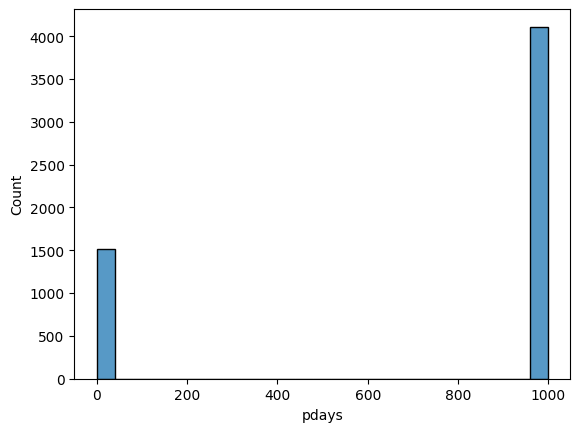

In [8]:
fig = sns.histplot(
    data=df.query('previous > 0'), 
    x="pdays",
    bins= 25
    )

Es el valor más utilizado. Hay que clarificar que significa el 999, si tambíen significa que ha sido mucho tiempo desde el último contacto.

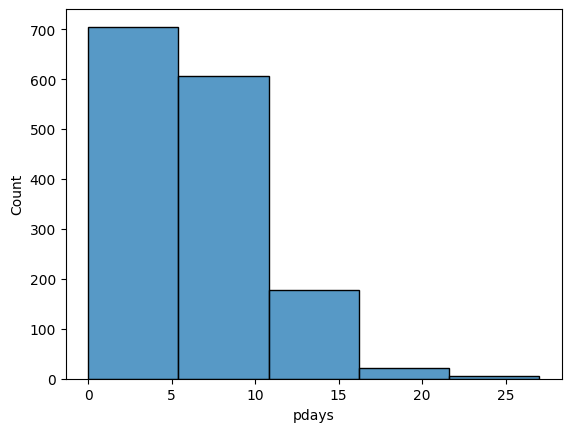

In [9]:
fig = sns.histplot(
    data=df.query('previous > 0 & pdays != 999'), 
    x="pdays",
    bins= 5
    )

Hay gente que han contactado bastante, pero la gran mayoría tienen menos de 10-11 intentos.

In [10]:
df.query('pdays != 999')['pdays'].describe().round(2)

count    1515.00
mean        6.01
std         3.82
min         0.00
25%         3.00
50%         6.00
75%         7.00
max        27.00
Name: pdays, dtype: float64

El máximo de días de contacto es 27 días, exceptuando los 999.

In [11]:
print(df['age'].value_counts())
print('-'*50)
print(df.age.unique())

age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
89       2
91       2
94       1
87       1
95       1
Name: count, Length: 78, dtype: int64
--------------------------------------------------
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]


Las personas más contactadas tienen una edad de 31 a 35 años.

In [12]:
df['campaign'].value_counts()

campaign
1     17642
2     10570
3      5341
4      2651
5      1599
6       979
7       629
8       400
9       283
10      225
11      177
12      125
13       92
14       69
17       58
16       51
15       51
18       33
20       30
19       26
21       24
22       17
23       16
24       15
27       11
29       10
28        8
26        8
25        8
31        7
30        7
35        5
32        4
33        4
34        3
42        2
40        2
43        2
56        1
39        1
41        1
37        1
Name: count, dtype: int64

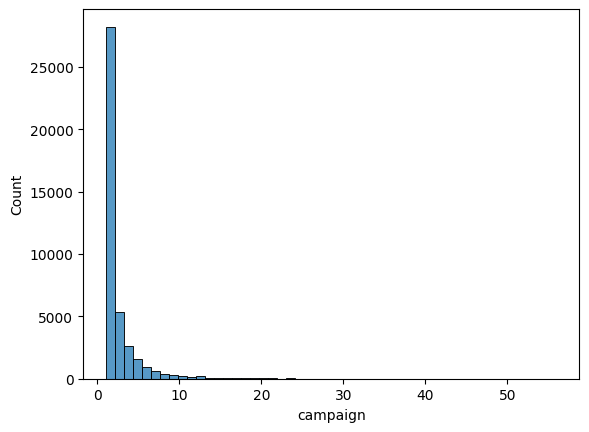

In [13]:
fig = sns.histplot(
    data=df, 
    x="campaign",
    bins= 50
    )

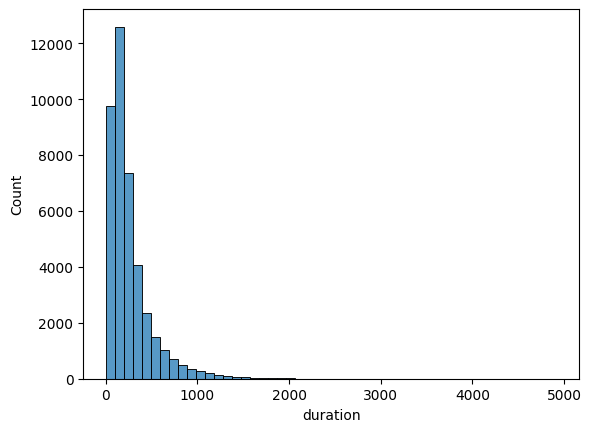

In [14]:
fig = sns.histplot(
    data=df, 
    x="duration",
    bins= 50
    )

-------

#### Valores Categoricos

In [15]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [16]:
df['education'].value_counts()

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [17]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [18]:
df['housing'].value_counts()

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

In [19]:
df['loan'].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

In [20]:
df['marital'].value_counts()

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

#### Campañas Previas

In [21]:
df['previous'].value_counts()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

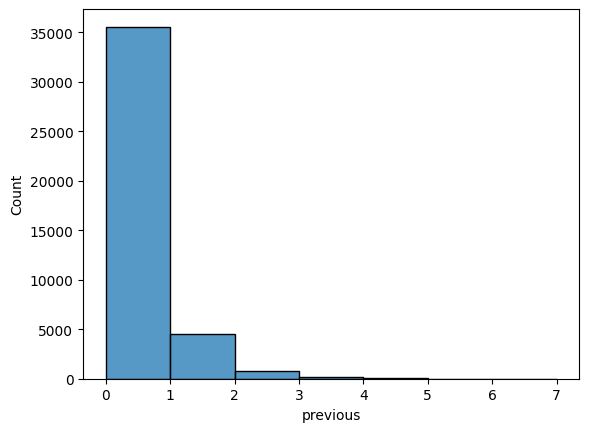

In [22]:
fig = sns.histplot(
    data=df, 
    x="previous",
    bins = 7
        )


In [23]:
df['poutcome'].value_counts()

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

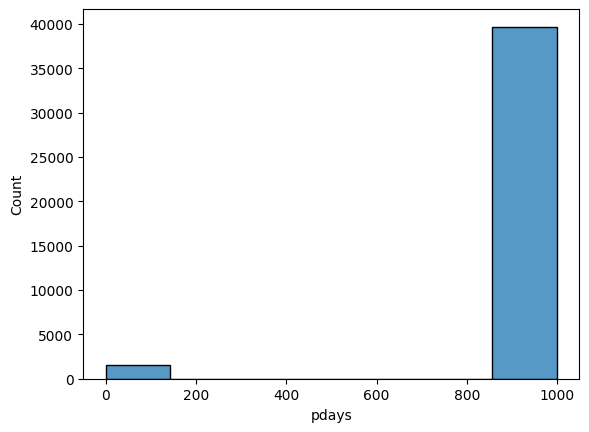

In [24]:
fig = sns.histplot(
    data=df, 
    x="pdays",
    bins = 7
        )


-----
#### Puntos de referencia - Euribor, Empleos, etc.

In [25]:
df[['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']].describe().round(2)

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00
mean,0.08,93.58,-40.50,3.62,5167.04
std,1.57,0.58,4.63,1.73,72.25
min,-3.40,92.20,-50.80,0.63,4963.60
25%,-1.80,93.08,-42.70,1.34,5099.10
50%,1.10,93.75,-41.80,4.86,5191.00
75%,1.40,93.99,-36.40,4.96,5228.10
max,1.40,94.77,-26.90,5.04,5228.10


In [26]:
df[['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']].agg(['median']).transpose()

,median
emp.var.rate,1.100
cons.price.idx,93.749
cons.conf.idx,-41.800
euribor3m,4.857
nr.employed,5191.000


-----


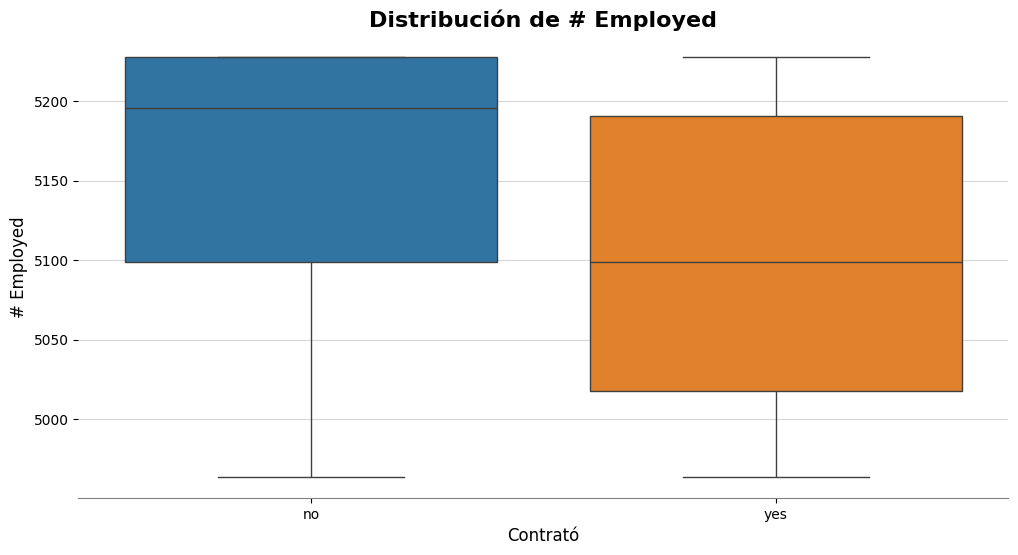

In [27]:
# TODO: configurar tamaño del plot (figsize=(12,6))
plt.figure(figsize=(12, 6))

# TODO: boxplot ventas vs mes
ax = sns.boxplot(
    data=df,
    y="nr.employed",
    x="y",
    hue="y",
    legend=False
    )

# TODO: añadir título al plot y a los ejes
ax.set_title("Distribución de # Employed", fontsize=16, fontweight="bold")
ax.set_xlabel("Contrató", fontsize=12)
ax.set_ylabel("# Employed", fontsize=12)

# TODO: personalizar el grid de fondo
ax.grid(alpha=0.5, drawstyle="steps", axis="y", linestyle="-")

# TODO: personalizar el marco del plot (spines)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("gray")

# TODO: show plot
plt.show()

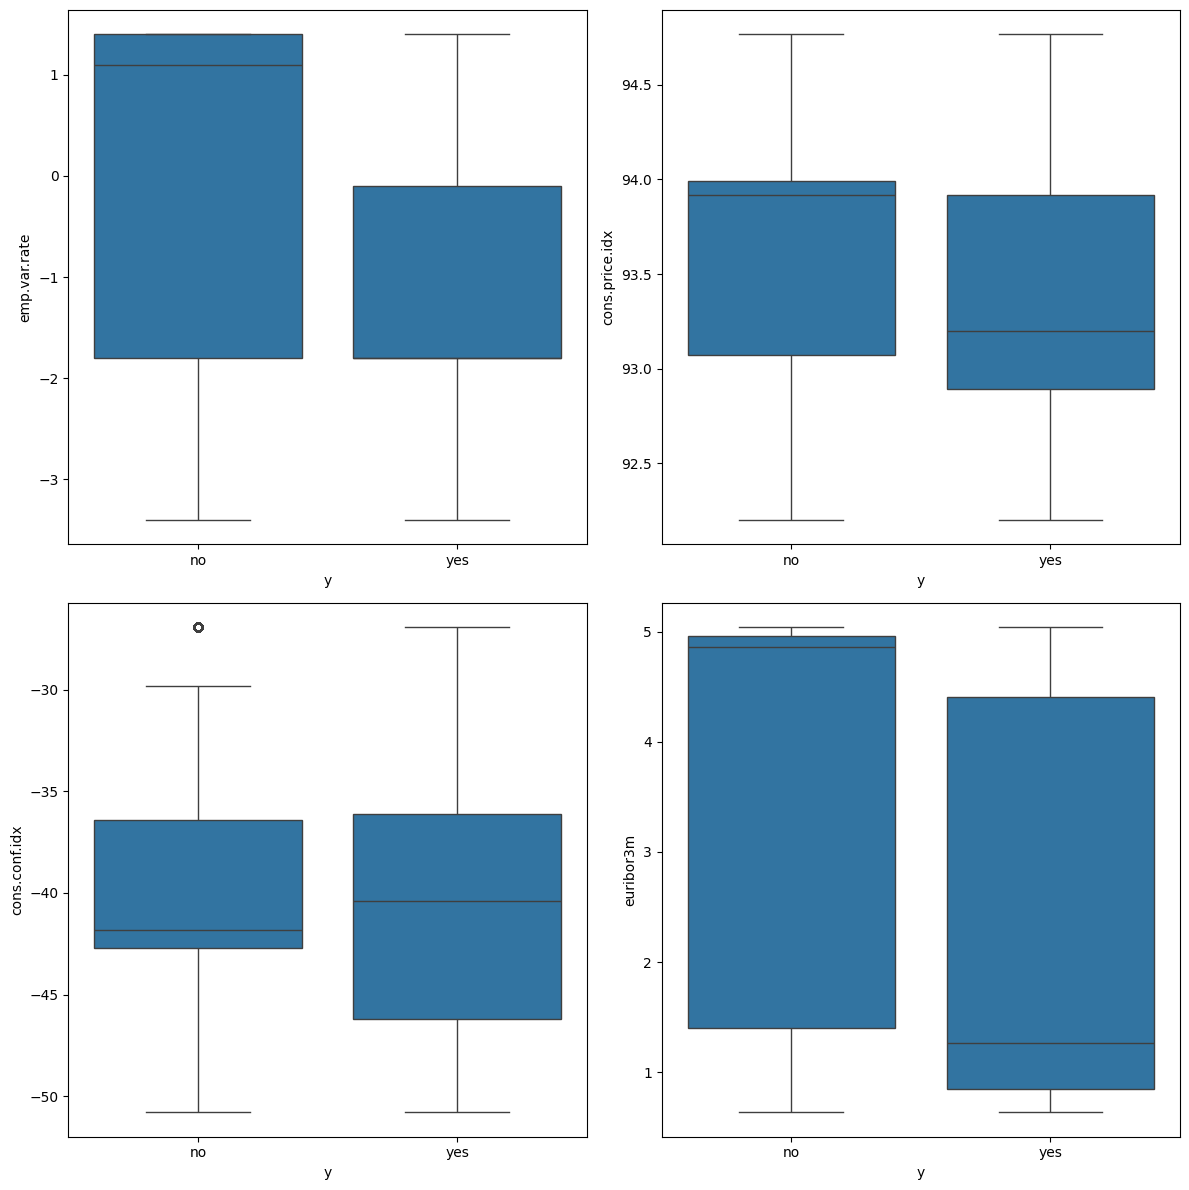

In [28]:
# TODO: iniciar el grid para el plot (3, 3, figsize=(12, 6))
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# TODO: aplanar todos los axes para poder recorrerlos todos en un solo bucle
axes_flat = axes.flatten()

# TODO: pintar cada scatterplot de forma 
lag_cols = ['emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']

for i, ax in enumerate(axes_flat):
    sns.boxplot(
        data=df,
        y=lag_cols[i],
        x="y",
        legend=False,
        ax=ax,  # pintamos sobre un ax ya existente
        )
    
# TODO: ajustar espacio entre plots
plt.tight_layout()

[⬆ Volver al índice](#indice)

<a id="analisis"></a>
## Análisis de los datos 🧠

### Tasa de Conversión Total

La tasa de conversión total de la campaña es **11%.**

In [29]:
(df.query('y == "yes"')['y'].count() / df['y'].count()).round(2)

np.float64(0.11)

In [30]:
df['y'].value_counts(normalize= True).round(2).reset_index().query('y=="yes"')['proportion']

1    0.11
Name: proportion, dtype: float64

### Empleos

Cúales tipos de empleos tienen las personas contactadas, y cúanta gente en total hay en cada grupo?

In [31]:
df.groupby('job')['y'].count().reset_index().rename({'y':'contacts'}, axis = 'columns').sort_values(by = 'contacts', ascending= False)

,job,contacts
0,admin.,10422
1,blue-collar,9254
9,technician,6743
7,services,3969
4,management,2924
5,retired,1720
2,entrepreneur,1456
6,self-employed,1421
3,housemaid,1060
10,unemployed,1014


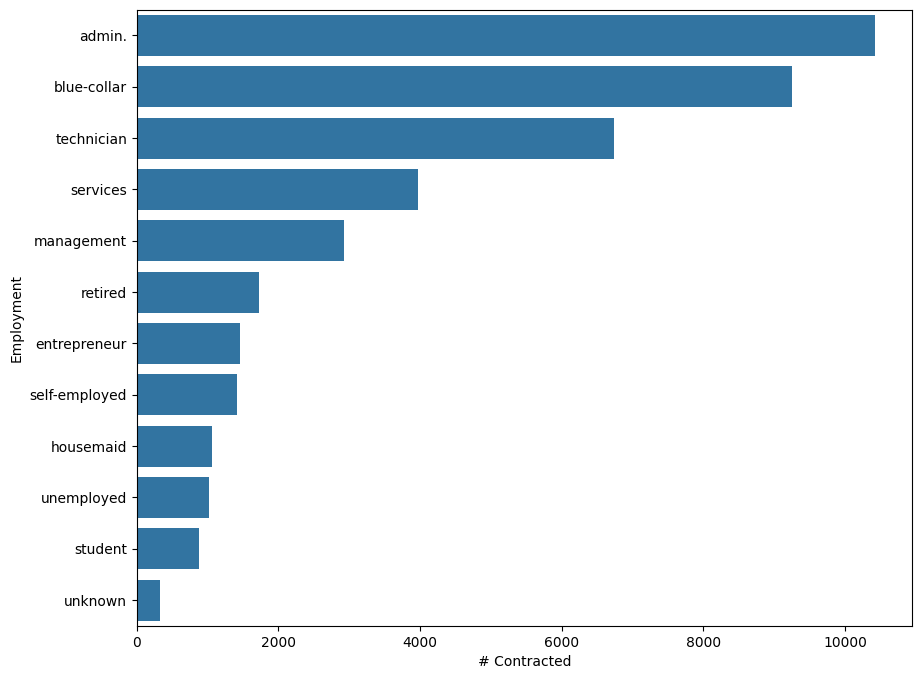

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))

df.groupby('job')['y'].count()

# df.groupby('job')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'job', columns = 'y', values = 'proportion')

ax = sns.barplot(
    df.groupby('job')['y'].count().reset_index().sort_values(by = 'y', ascending= False),
    x = 'y',
    y = 'job'
)

ax.set(xlabel='# Contracted', ylabel='Employment')

plt.show()

Qué es la proporción de gente que dijó "Sí" basado a nuestro contacto, por trabajo?

In [33]:
df.groupby('job')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'job', columns = 'y', values = 'proportion').rename(columns={'no':'No','yes':'Contracted'})

y,No,Contracted
job,,
admin.,0.87,0.13
blue-collar,0.93,0.07
entrepreneur,0.91,0.09
housemaid,0.90,0.10
management,0.89,0.11
retired,0.75,0.25
self-employed,0.90,0.10
services,0.92,0.08
student,0.69,0.31


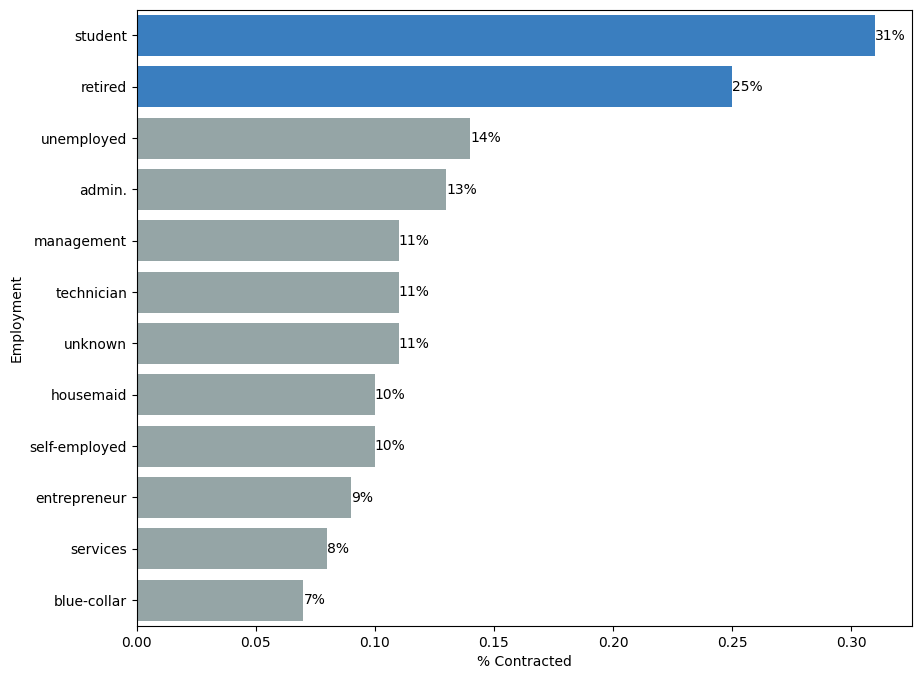

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))

ax = sns.barplot(
    df.groupby('job')['y']
      .value_counts(normalize=True)
      .round(2)
      .reset_index()
      .pivot(index='job', columns='y', values='proportion')
      .sort_values(by='yes', ascending=False),
    x='yes',
    y='job'
)

ax.set(xlabel='% Contracted', ylabel='Employment')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

for i, patch in enumerate(ax.patches):
    if i < 2:
        patch.set_facecolor("#3a7ebf") 
    else:
        patch.set_facecolor('#95a5a6') 

plt.show()

### Modo de Contacto

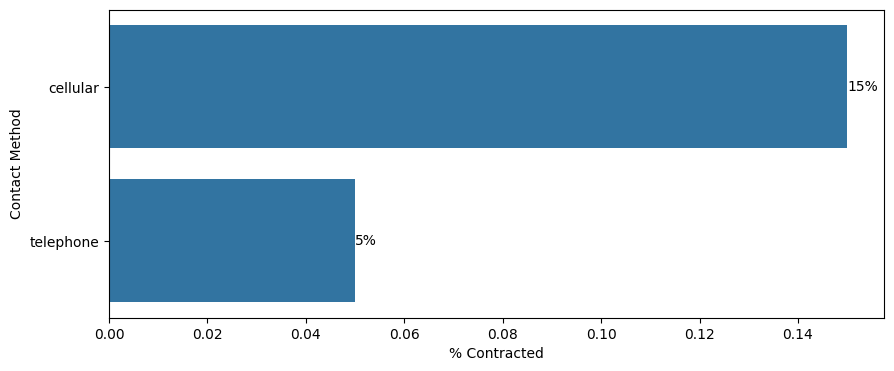

In [ ]:
# EXTRA

fig, ax = plt.subplots(figsize=(10, 4))

ax = sns.barplot(
    df.groupby(['contact'])['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"'),
    x = 'proportion',
    y = 'contact'
)

ax.set(xlabel='% Contracted', ylabel='Contact Method')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

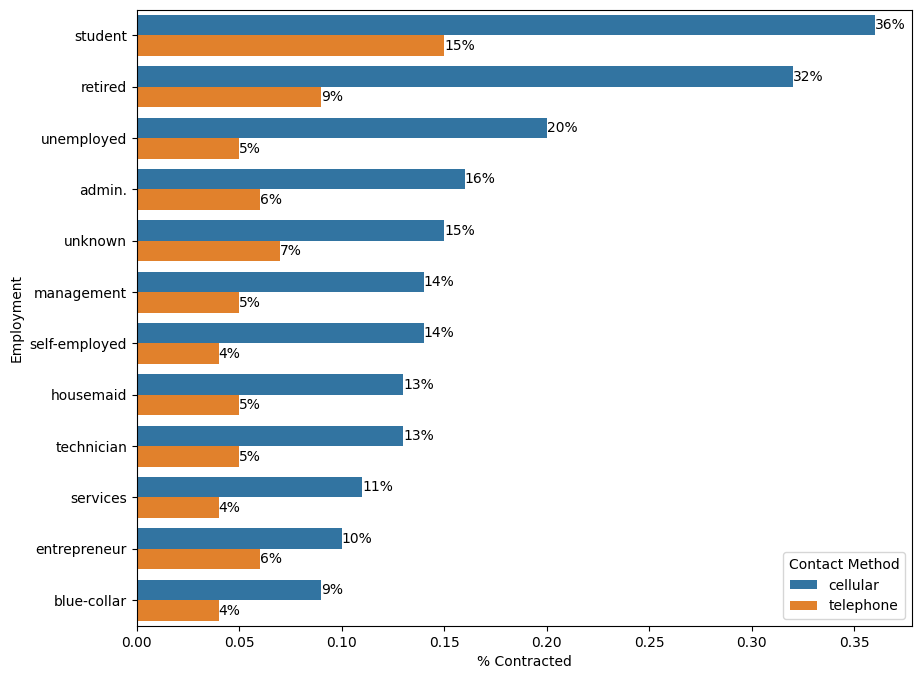

In [ ]:
# EXTRA

ax = plt.subplots(figsize=(10, 8))

ax = sns.barplot(
    df.groupby(['job','contact'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['job','contact'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'job',
    hue = 'contact'
)

ax.set(xlabel='% Contracted', ylabel='Employment')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.legend(title='Contact Method')


plt.show()

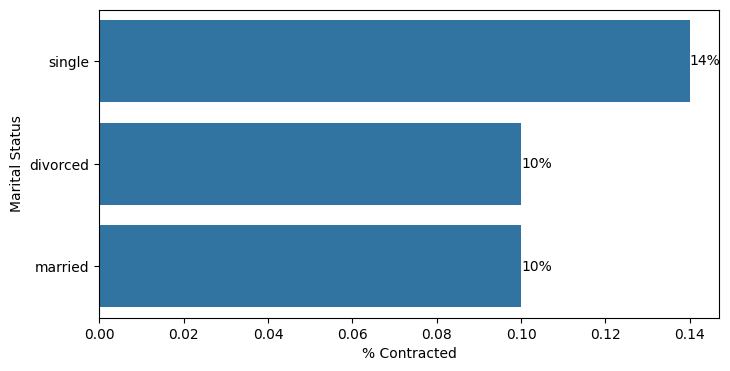

In [37]:
ax = plt.subplots(figsize=(8, 4))

ax = sns.barplot(
    df.query('marital != "unknown"').groupby('marital')['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= 'marital', columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'marital'
)

ax.set(xlabel='% Contracted', ylabel='Marital Status')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

# ax.bar_label(ax.containers[0], fontsize=10)

plt.show()

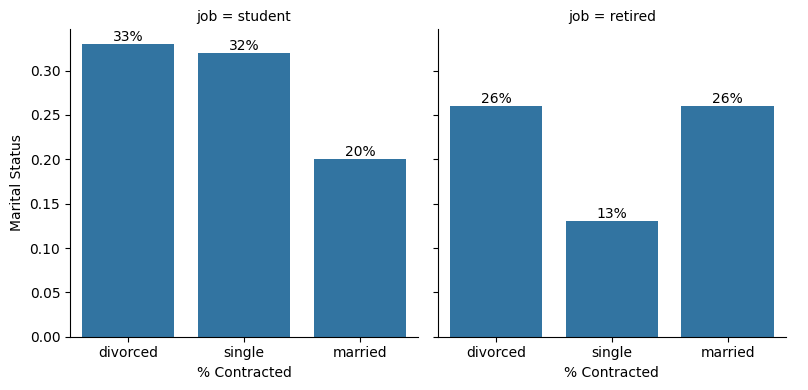

In [38]:
# Unknown represents 80 out of 41k columns. Remove. Also removing unknown job people since that is also less than 1%.

# fig, ax = plt.subplots(figsize=(6, 12))

ax = sns.catplot(
    data= df.query('job == "student" | job == "retired"').groupby(['marital','job'])['y'].value_counts(normalize= True).round(2).reset_index().query('marital != "unknown"').pivot(index= ['marital','job'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "marital", 
    y= "yes", 
    col= "job",
    kind="bar", height=4, aspect=1
)

for ax in ax.axes.flat:
    ax.set(xlabel='% Contracted', ylabel='Marital Status')
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

#### Duración de Llamada

Cambiamos los segundos a minutos.

In [39]:
df['duration_minutes'] = df['duration'] / 60

El promedio de las llamadas son a 4.3 minutos.

In [40]:
df.duration.describe() / 60

count    686.466667
mean       4.304750
std        4.321321
min        0.000000
25%        1.700000
50%        3.000000
75%        5.316667
max       81.966667
Name: duration, dtype: float64

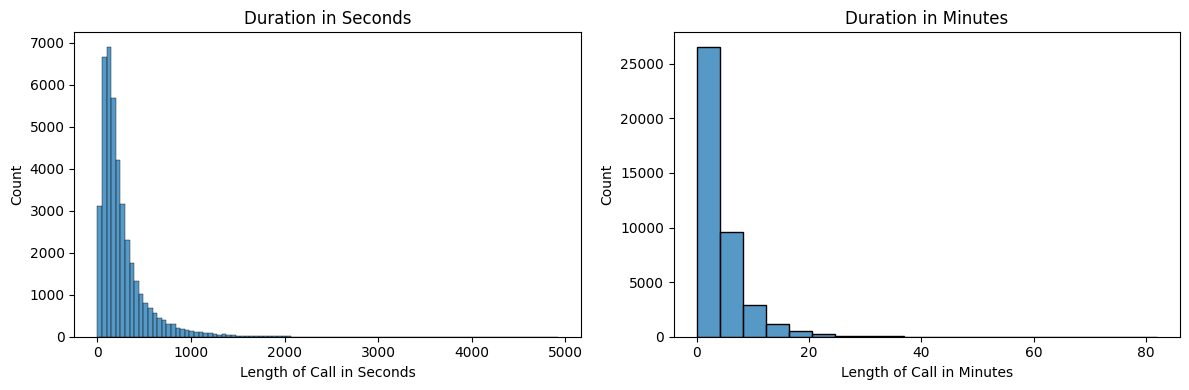

In [ ]:
# ERTRA

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=df, 
    x="duration",
    bins= 100,
    ax=ax1
    )

sns.histplot(
    data=df, 
    x="duration_minutes",
    bins= 20,
    ax= ax2
    )

ax1.set_title('Duration in Seconds')
ax2.set_title('Duration in Minutes')

ax1.set_xlabel('Length of Call in Seconds')
ax2.set_xlabel('Length of Call in Minutes')

plt.tight_layout()
plt.show()

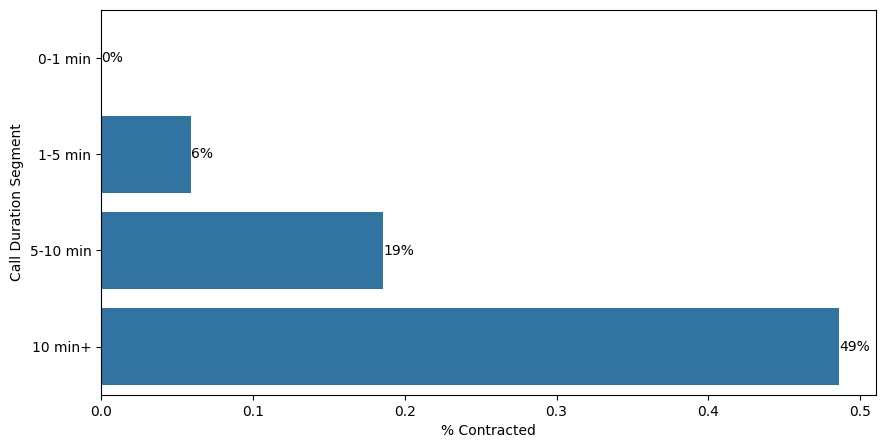

In [ ]:
# EXTRA

bins = [0, 60, 300, 600, np.inf]
names = ['0-1 min', '1-5 min', '5-10 min', '10 min+']

df['duration_segment'] = pd.cut(df['duration'], bins, labels=names)

fig, ax = plt.subplots(figsize=(10, 5))

ax = sns.barplot(
    df.groupby('duration_segment', observed= True)['y'].value_counts(normalize= True).reset_index().pivot(index= 'duration_segment', columns = 'y', values = 'proportion'),
    x = 'yes',
    y = 'duration_segment'
)

ax.set(xlabel='% Contracted', ylabel='Call Duration Segment')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

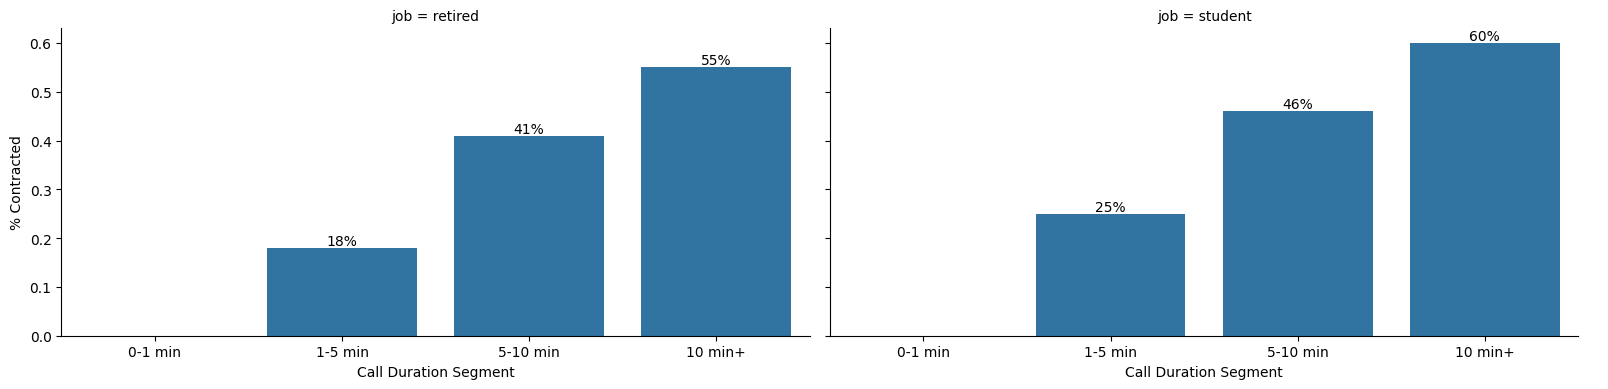

In [52]:
ax = sns.catplot(
    data= df.query('job == "student" | job == "retired"').groupby(['job','duration_segment'], observed= True)['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"'),
    x= "duration_segment", 
    y= "proportion", 
    col= "job",
    kind="bar", height=4, aspect=2
)

for ax in ax.axes.flat:
    ax.set(ylabel='% Contracted', xlabel='Call Duration Segment')
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

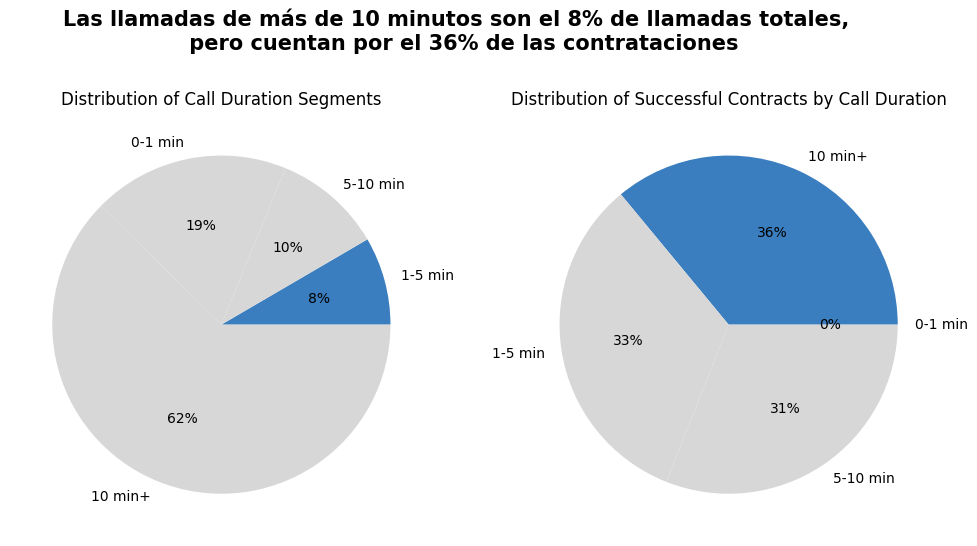

In [43]:
"""
15 min +             956
10 min - 15 min     2508
0-1 min             4282
5-10 min            7740
1-5 min            25698
"""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Count of call duration segments
labels1 = ['1-5 min','5-10 min','0-1 min','10 min+']
total1 = df.groupby('duration_segment', observed= True)['y'].count().sort_values(ascending= True)


ax1.pie(total1, labels= labels1, colors= ["#3a7ebf"]  + ['#d7d7d7'] * (len(labels1) - 1), autopct= '%1.0f%%')
ax1.set_title('Distribution of Call Duration Segments')

# Count of Successful Contracted
labels2 = ['10 min+','1-5 min','5-10 min','0-1 min']
total2 = df.query('y == "yes"')['duration_segment'].value_counts(normalize = True).round(2).sort_values(ascending= False)

ax2.pie(total2, labels = labels2, colors= ["#3a7ebf"] + ['#d7d7d7'] * (len(labels2) - 1),  autopct='%1.0f%%')
ax2.set_title('Distribution of Successful Contracts by Call Duration')

plt.suptitle('Las llamadas de más de 10 minutos son el 8% de llamadas totales, \n pero cuentan por el 36% de las contrataciones', fontsize=15, fontweight='bold', y=1.02)

plt.show()

# colors= ["#3a7ebf","#d7d7d7","#d7d7d7","#d7d7d7"]
# %1.1f%%'
# lambda p: f'{p:1.0f}%' if p > 0 else ''

### Intentos Previos

Categorizamos los clientes si lo habíamos contactado anteriormente: 
- Prospect, si nunca le hayamos contactado.
- Retargeting, si les hayamos contactado por lo menos una (1) vez.

In [44]:
df['previously_attempted'] = df['previous'].apply(lambda x: previouslyContacted(x))

In [45]:
df['previously_attempted'].value_counts()

previously_attempted
Prospect       35563
Retargeting     5625
Name: count, dtype: int64

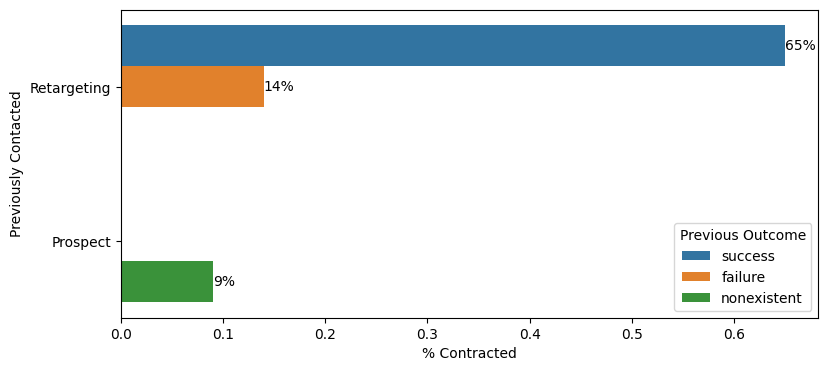

In [46]:
ax = plt.subplots(figsize=(9, 4))

ax = sns.barplot(
    df.groupby(['previously_attempted','poutcome'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','poutcome'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'previously_attempted',
    hue = 'poutcome',
)

# ax.bar_label(ax.containers[0], fontsize=10)
# ax.bar_label(ax.containers[1], fontsize=10)
# ax.bar_label(ax.containers[2], fontsize=10)

ax.set(xlabel='% Contracted', ylabel='Previously Contacted')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.legend(title='Previous Outcome')

plt.show()

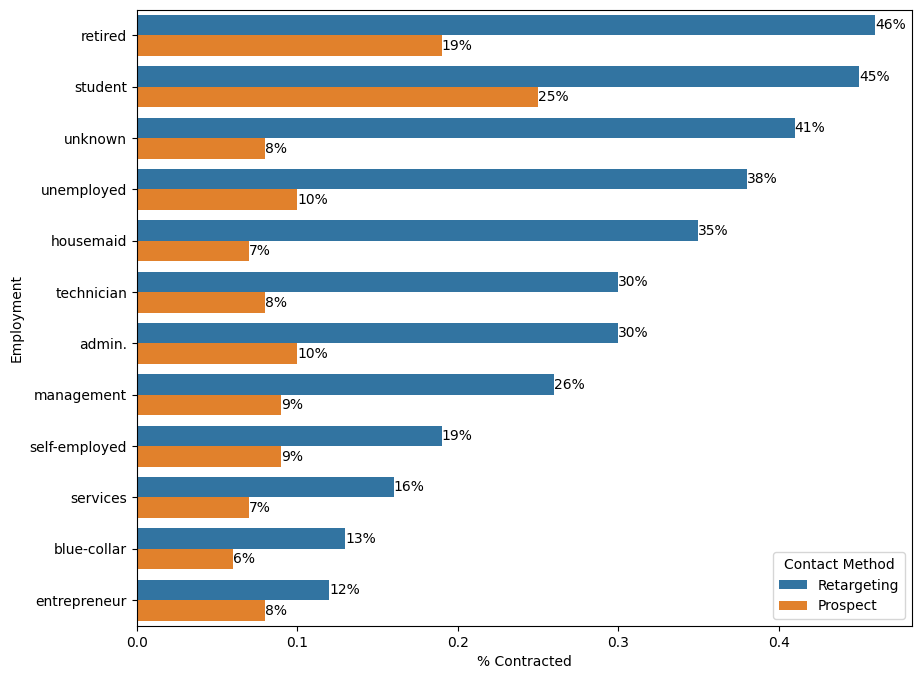

In [ ]:
# UNIFICAR LOS DEMAS APARTE DE JUBILADOS Y ESTUDIANTES

ax = plt.subplots(figsize=(10, 8))

ax = sns.barplot(
    df.groupby(['job','previously_attempted'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['job','previously_attempted'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x = 'yes',
    y = 'job',
    hue = 'previously_attempted'
)

ax.set(xlabel='% Contracted', ylabel='Employment')

for container in ax.containers:
    ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.legend(title='Contact Method')


plt.show()

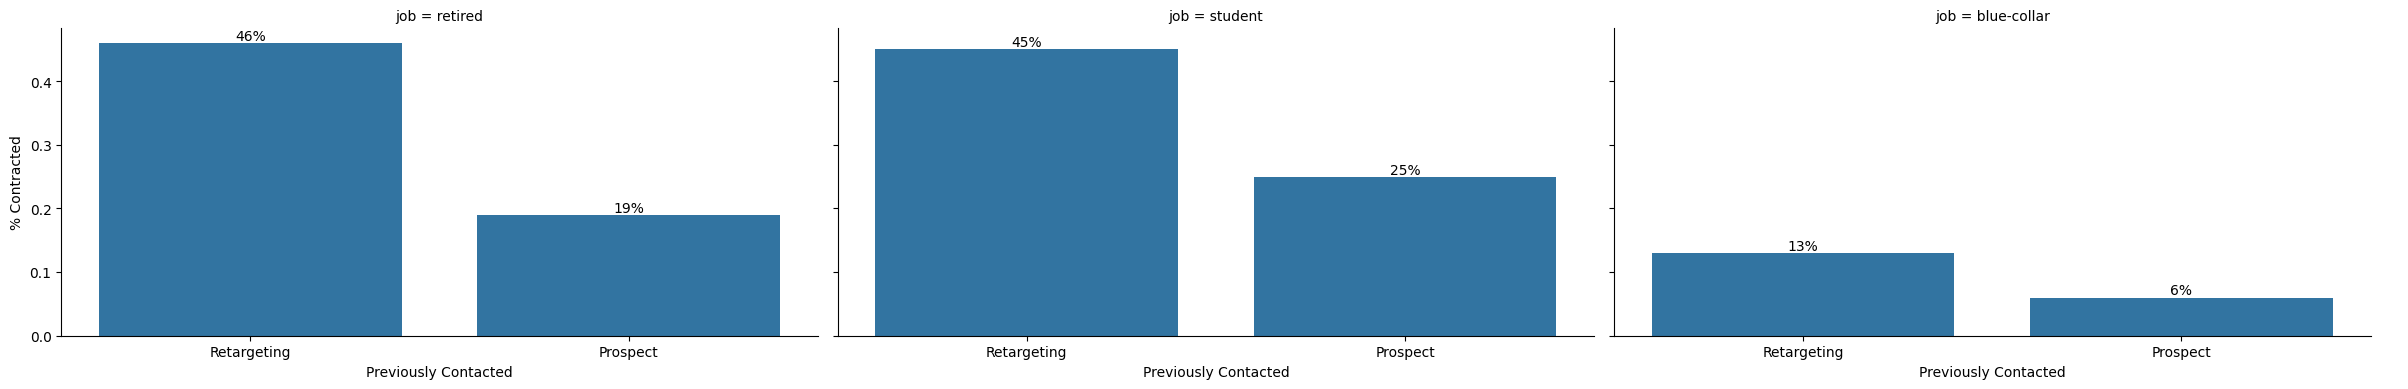

In [56]:


ax = sns.catplot(
    data= df.query('job == "student" | job == "retired" | job == "blue-collar"').groupby(['previously_attempted','job'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['previously_attempted','job'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "previously_attempted", 
    y= "yes", 
    col= "job",
    kind="bar", height=4, aspect=2
)

for ax in ax.axes.flat:
    ax.set(ylabel='% Contracted', xlabel='Previously Contacted')
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

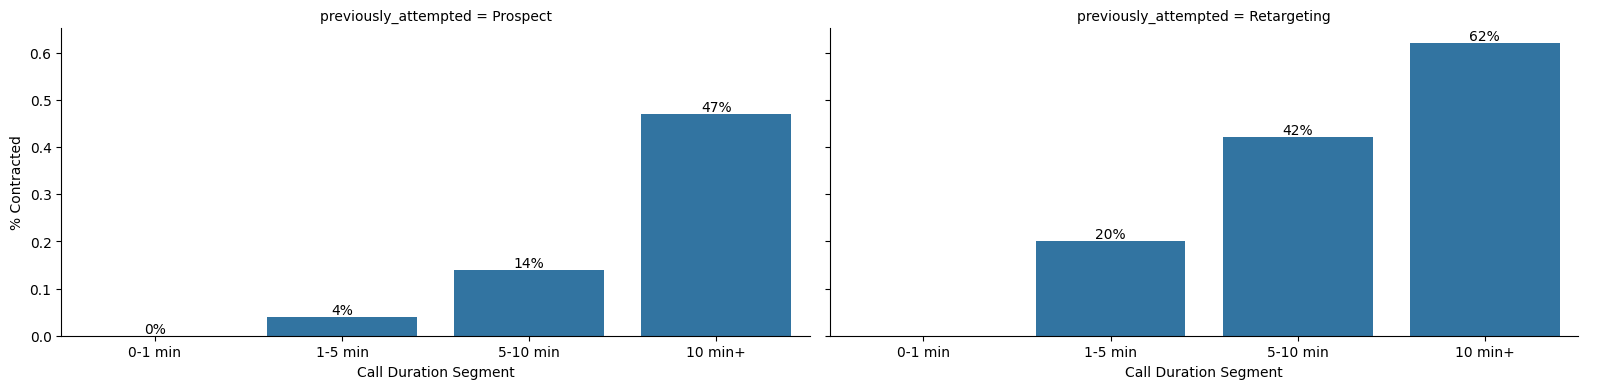

In [48]:
ax = sns.catplot(
    data= df.groupby(['previously_attempted','duration_segment'], observed= True)['y'].value_counts(normalize= True).round(2).reset_index().query('y == "yes"'),
    x= "duration_segment", 
    y= "proportion", 
    col= "previously_attempted",
    kind="bar", height=4, aspect=2
)

for ax in ax.axes.flat:
    ax.set(ylabel='% Contracted', xlabel='Call Duration Segment')
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fmt=lambda x: f'{x:.0%}')

plt.show()

In [49]:
(df.groupby(['previously_attempted','y'])['duration_minutes'].mean()).reset_index().pivot(index= 'previously_attempted', columns = 'y', values= 'duration_minutes').round(2)

y,no,yes
previously_attempted,,
Prospect,3.69,10.39
Retargeting,3.59,6.76


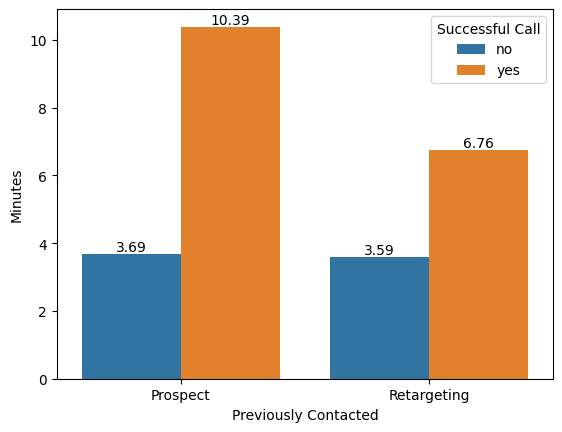

In [50]:
data = (df.groupby(['previously_attempted','y'])['duration_minutes'].mean()).reset_index().round(2)

ax = sns.barplot(
    data=data,
    x='previously_attempted',
    y='duration_minutes',
    hue='y'
)

ax.set(xlabel='Previously Contacted', ylabel='Minutes')
plt.legend(title='Successful Call')


for container in ax.containers:
    ax.bar_label(container, fontsize=10)

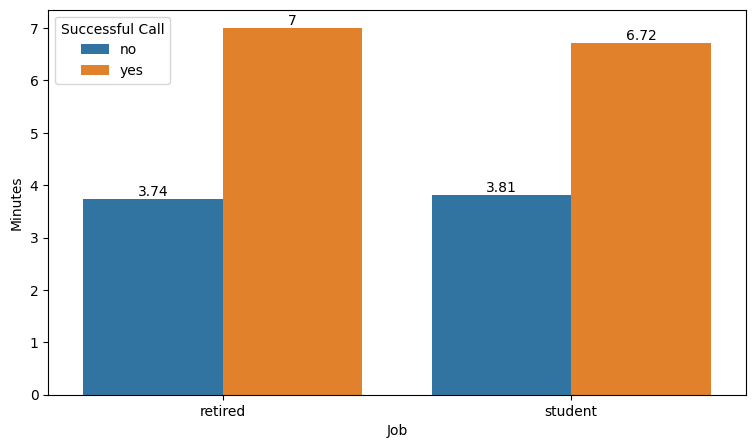

In [51]:
ax = plt.subplots(figsize=(9, 5))

data = (df.query('job == "student" | job == "retired"').groupby(['job','y'])['duration_minutes'].mean()).reset_index().round(2)

ax = sns.barplot(
    data=data,
    x='job',
    y='duration_minutes',
    hue='y'
)

ax.set(xlabel='Job', ylabel='Minutes')
plt.legend(title='Successful Call')


for container in ax.containers:
    ax.bar_label(container, fontsize=10)

### Campaña Corriente - Mes o Día de la Semana y Cuantas veces hemos contactado

In [53]:
df['season'] = df['month'].apply(lambda x: seasons(x))

<Axes: xlabel='proportion', ylabel='season'>

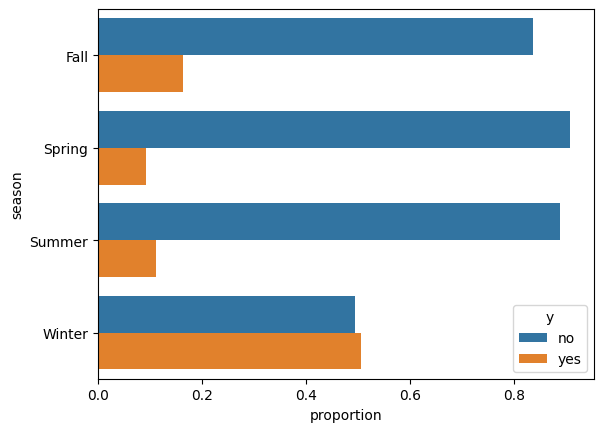

In [ ]:
# Make graphic with r/s segments

sns.barplot(
    df.groupby('season')['y'].value_counts(normalize= True).reset_index(),
    x = 'proportion',
    y = 'season',
    hue = 'y'
)

<Axes: xlabel='proportion', ylabel='day_of_week'>

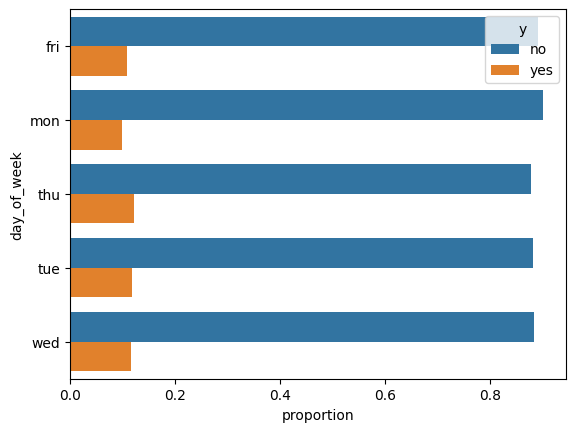

In [ ]:
# Make graphic with r/s segments

sns.barplot(
    df.groupby('day_of_week')['y'].value_counts(normalize= True).reset_index(),
    x = 'proportion',
    y = 'day_of_week',
    hue = 'y'
)
# .pivot(index= 'day_of_week', columns = 'y', values = 'proportion')

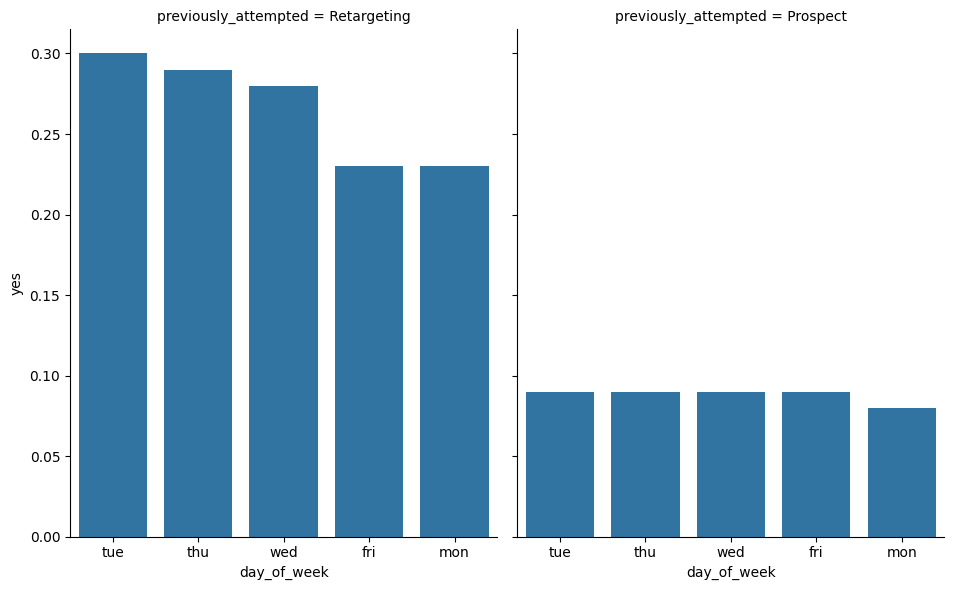

In [ ]:
# Make graphic with r/s segments

sns.catplot(
    data= df.groupby(['day_of_week','previously_attempted'])['y'].value_counts(normalize= True).round(2).reset_index().pivot(index= ['day_of_week','previously_attempted'], columns = 'y', values = 'proportion').sort_values(by = 'yes', ascending= False),
    x= "day_of_week", 
    y= "yes", 
    col= "previously_attempted",
    kind="bar", height=6, aspect=0.8
)

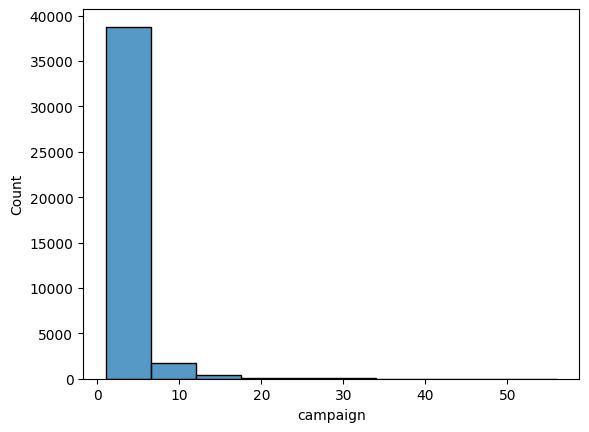

In [87]:
fig = sns.histplot(
    data=df, 
    x="campaign",
    bins = 10
    )


In [88]:
bins = [0,1,2,5,10,np.inf]
names = ['0 times', '1x', '2-5x', '5-10x','10x +']

df['campaign_segment'] = pd.cut(df['campaign'], bins, labels=names)

/var/folders/4k/9hthz5210ms6_s09wx9tymvw0000gn/T/ipykernel_68972/877455002.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['campaign_segment','previously_attempted'])['y'].value_counts(normalize= True).reset_index().query('y == "yes"'),


<Axes: xlabel='campaign_segment', ylabel='proportion'>

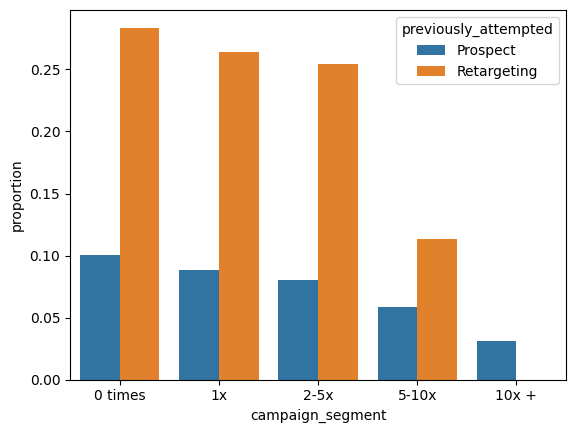

In [ ]:
# Make graphic with r/s segments

sns.barplot(
    df.groupby(['campaign_segment','previously_attempted'])['y'].value_counts(normalize= True).reset_index().query('y == "yes"'),
    x = 'campaign_segment',
    y = 'proportion',
    hue = 'previously_attempted'
)


#### Edad

Dividimos edades en rangos para ver categoricamente. Los "bins" son inclusivos al valor máximo especificado en pd.cut (right = True)

In [99]:
bins = [0,25, 35, 45, 55, 65, np.inf]
names = ['<25', '26-35', '36-45', '46-55','56-65','66+']

df['age_segment'] = pd.cut(df['age'], bins, labels=names, right= True)

/var/folders/4k/9hthz5210ms6_s09wx9tymvw0000gn/T/ipykernel_68972/937568350.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_segment','previously_attempted'])['y'].value_counts(normalize= True).reset_index().query('y == "yes"'),


<Axes: xlabel='proportion', ylabel='age_segment'>

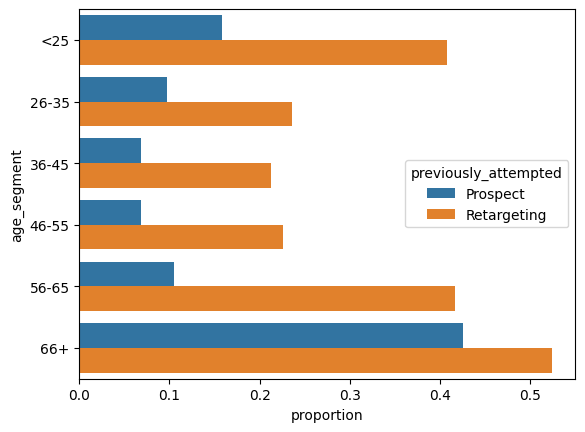

In [ ]:
# EXTRA

sns.barplot(
    df.groupby(['age_segment','previously_attempted'])['y'].value_counts(normalize= True).reset_index().query('y == "yes"'),
    x = 'proportion',
    y = 'age_segment',
    hue = 'previously_attempted'
)


##

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\2596561446.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'age_segment', columns = 'y', values = 'proportion'),


<Axes: xlabel='yes', ylabel='age_segment'>

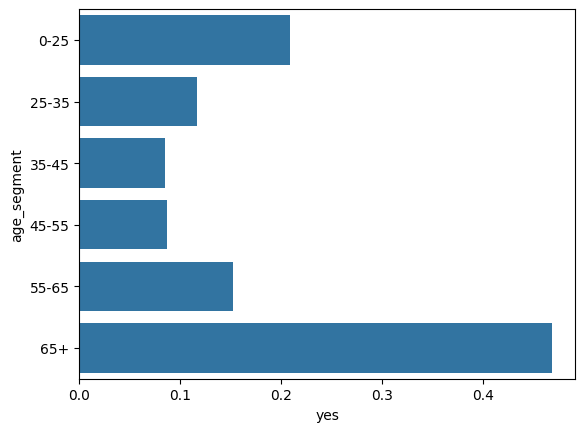

In [ ]:
# EXTRA

bins = [0,25, 35, 45, 55, 65, np.inf]
names = ['0-25', '25-35', '35-45', '45-55','55-65','65+']

df['age_segment'] = pd.cut(df['age'], bins, labels=names)

sns.barplot(
    df.groupby('age_segment')['y'].value_counts(normalize= True).reset_index().pivot(index= 'age_segment', columns = 'y', values = 'proportion'),
    x = 'yes',
    y = 'age_segment'
)

### Duracion de las llamadas

In [ ]:
# EXTRA

# voy a quitar los outliers de la duration ya que pueden crear malentendidos
limite_inferior, limite_superior = limites_outliers(df,'duration')

Valor del segundo cuartil (25%): 102.00
Valor del tercer cuartil (75%): 319.00
Valor del rango intercuartil (IQR): 217.00
Los valores atípicos se definen como aquellos que caen fuera del siguiente rango:
	 - Límite inferior (considerado extremadamente bajo): -223.50
	 - Límite superior (considerado extremadamente alto): 644.50


In [ ]:
# EXTRA

df_sin_outliers = df[(df['duration'] >= limite_inferior) & (df['duration'] <= limite_superior)]

<Axes: xlabel='duration', ylabel='y'>

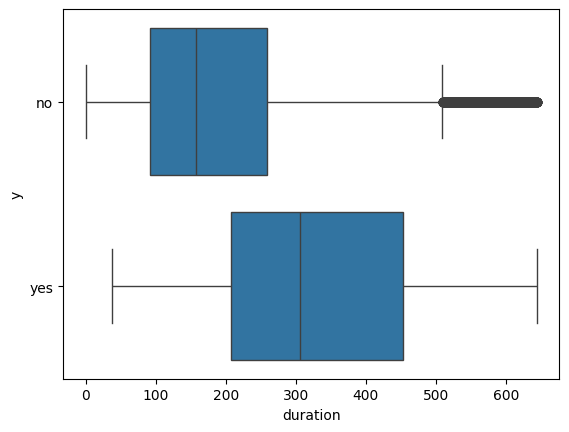

In [ ]:
# EXTRA

sns.boxplot(x='duration', y='y', data=df_sin_outliers)

In [ ]:
# EXTRA

pd.crosstab(df_sin_outliers['job'] , df_sin_outliers['duration'])

duration,0,1,2,3,4,5,6,7,8,9,...,635,636,637,638,639,640,641,642,643,644
job,,,,,,,,,,,,,,,,,,,,,
admin.,1,0,0,1,5,7,11,17,16,22,...,3,2,1,5,4,0,4,2,6,2
blue-collar,2,1,0,1,3,8,4,12,16,17,...,3,2,3,1,0,2,2,2,2,2
entrepreneur,0,0,1,0,0,1,1,4,6,4,...,0,1,1,1,1,0,1,1,0,0
housemaid,0,0,0,0,0,0,0,1,1,5,...,0,0,1,1,0,0,0,0,0,0
management,1,0,0,0,1,1,0,2,8,2,...,0,2,2,3,0,2,1,0,0,1
retired,0,1,0,0,0,0,0,1,1,2,...,0,0,0,0,0,0,0,0,0,0
self-employed,0,0,0,0,1,2,1,0,2,2,...,0,0,0,0,1,1,0,0,1,1
services,0,1,0,0,0,3,6,4,4,8,...,1,2,0,0,1,2,0,1,3,0
student,0,0,0,0,0,2,3,2,0,3,...,0,0,1,0,0,0,0,1,0,0


In [ ]:
# EXTRA

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['0-25', '25-35', '35-45', '45-55', '55-65', '+65']

df_sin_outliers['intervalo_edad'] = pd.cut(
    df_sin_outliers['age'],
    bins=bins, 
    labels = labels,
    right = False,
    ordered=True
)

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\4283991724.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sin_outliers['intervalo_edad'] = pd.cut(


In [ ]:
# EXTRA

pd.crosstab(df_sin_outliers['intervalo_edad'] , df_sin_outliers['duration'])

duration,0,1,2,3,4,5,6,7,8,9,...,635,636,637,638,639,640,641,642,643,644
intervalo_edad,,,,,,,,,,,,,,,,,,,,,
0-25,0,0,0,0,0,1,1,3,2,4,...,0,0,1,1,0,1,0,1,0,0
25-35,1,0,0,1,6,15,22,18,22,27,...,0,3,4,4,2,2,6,2,10,2
35-45,1,2,0,1,3,6,8,17,25,18,...,7,3,2,8,3,4,2,4,3,4
45-55,1,0,1,1,2,5,4,11,16,21,...,2,4,4,0,4,0,1,3,2,2
55-65,1,0,0,0,1,3,2,5,4,7,...,1,0,0,1,0,2,1,0,0,2
+65,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


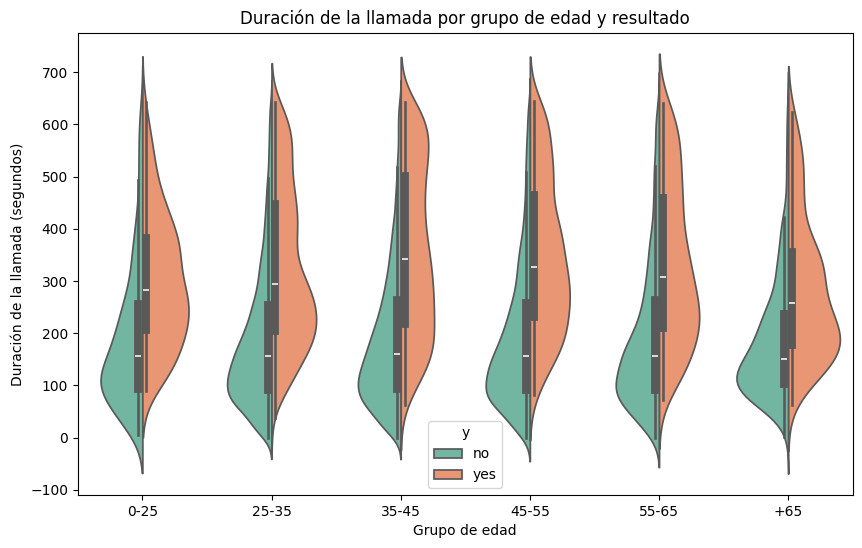

In [ ]:
# EXTRA

plt.figure(figsize=(10,6))
sns.violinplot(x='intervalo_edad', y='duration', hue='y', data=df_sin_outliers, split=True, palette='Set2')
plt.title('Duración de la llamada por grupo de edad y resultado')
plt.ylabel('Duración de la llamada (segundos)')
plt.xlabel('Grupo de edad')
plt.show()

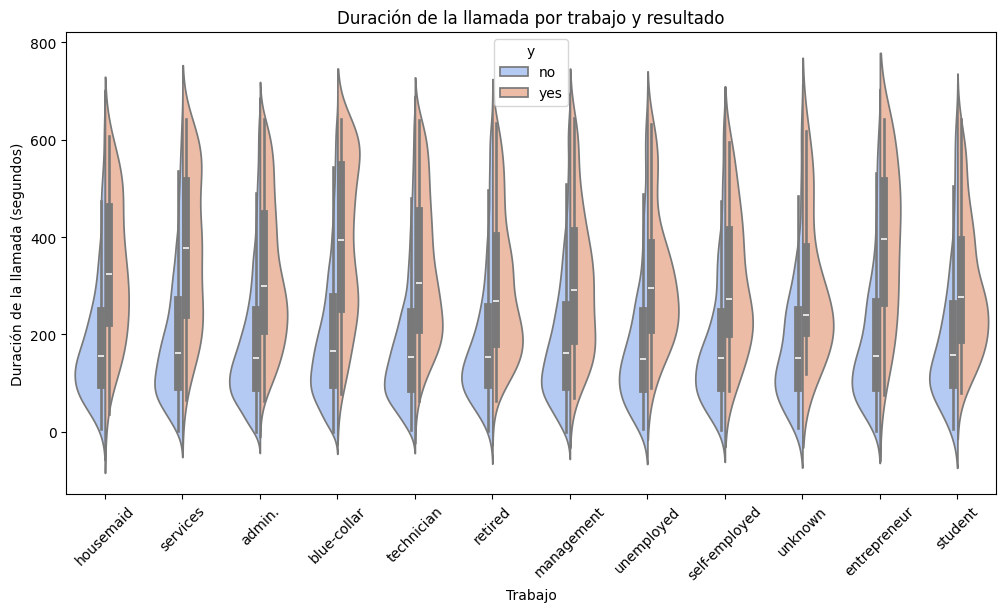

In [ ]:
# EXTRA

plt.figure(figsize=(12,6))
sns.violinplot(x='job', y='duration', hue='y', data=df_sin_outliers, split=True, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Duración de la llamada por trabajo y resultado')
plt.ylabel('Duración de la llamada (segundos)')
plt.xlabel('Trabajo')
plt.show()

### Cruces finales

C:\Users\migue\AppData\Local\Temp\ipykernel_1504\3551491320.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_age_job = df_sin_outliers.groupby(['intervalo_edad','job'])['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()


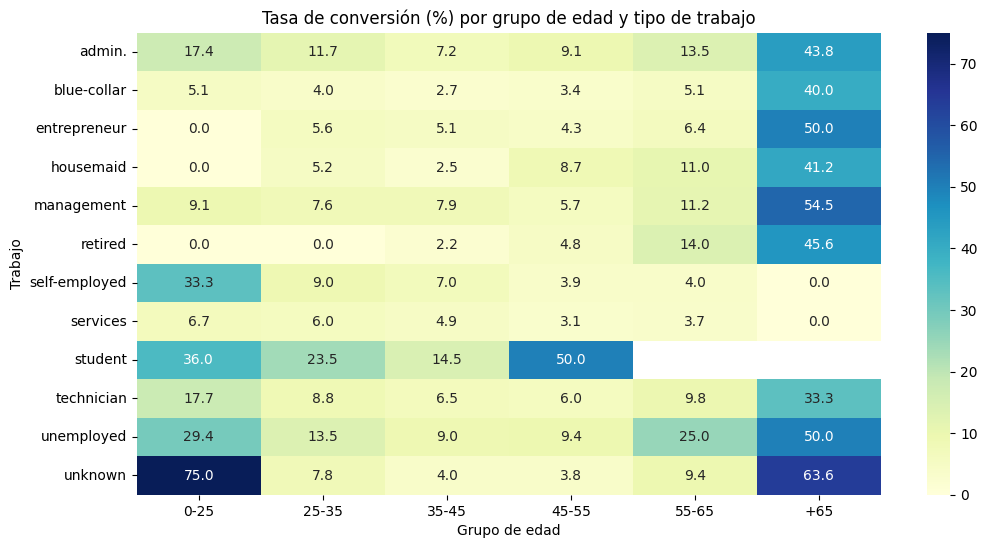

In [ ]:
# EXTRA

df_age_job = df_sin_outliers.groupby(['intervalo_edad','job'])['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()
df_age_job_pivot = df_age_job.pivot(index='job', columns='intervalo_edad', values='y')

plt.figure(figsize=(12,6))
sns.heatmap(df_age_job_pivot, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Tasa de conversión (%) por grupo de edad y tipo de trabajo')
plt.ylabel('Trabajo')
plt.xlabel('Grupo de edad')
plt.show()

[⬆ Volver al índice](#indice)

<a id="conclusiones"></a>
## Conclusiones 📝

En esta sección se resumen los principales hallazgos del análisis de las campañas de marketing del banco.

[⬆ Volver al índice](#indice)